# ***Start***

### ***Import Libraries***

In [1645]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import sklearn
import mplsoccer as mpl
from mplsoccer import Pitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

### ***Notebook Settings***

In [1646]:
pd.set_option('display.max_columns', None)  # Show all columns
"""
pd.set_option('display.max_rows', None)     # Show all rows (optional, careful if very large!)
pd.set_option('display.max_colwidth', None) # Optional: expand the column width
pd.set_option('display.width', 200) # Optional: display width to prevent wrapping
"""

"\npd.set_option('display.max_rows', None)     # Show all rows (optional, careful if very large!)\npd.set_option('display.max_colwidth', None) # Optional: expand the column width\npd.set_option('display.width', 200) # Optional: display width to prevent wrapping\n"

### ***Import Data***

In [1647]:
data = pd.read_excel("data/clean_data.xlsx")
data.head()

,x,y,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,BigChance,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OtherBodyPart,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,is_goal
0,80.8,51.6,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
1,79.3,24.2,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
2,80.0,59.5,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
3,89.8,55.6,True,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
4,84.9,56.2,True,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False


# ***Footedness & Zonal Analysis***

***This analysis investigates the relationship between shot location and footedness by examining where goals are scored using the left and right foot. By analyzing spatial patterns, we aim to uncover tendencies in finishing behavior and assess whether certain pitch areas favor specific foot usage.***

- ***Right side of the pitch &rarr; Y<=34***
- ***Center of the pitch &rarr; 34<Y<66***
- ***Left side of the pitch &rarr; Y>=66***

In [1648]:
data.columns

Index(['x', 'y', 'Assisted', 'IndividualPlay', 'RegularPlay', 'LeftFoot',
       'RightFoot', 'FromCorner', 'FirstTouch', 'Head', 'BigChance',
       'SetPiece', 'Volley', 'FastBreak', 'ThrowinSetPiece', 'Penalty',
       'OneOnOne', 'KeyPass', 'DirectFreekick', 'OtherBodyPart',
       'period_FirstHalf', 'period_SecondHalf', 'Zone_Back', 'Zone_Center',
       'Zone_Left', 'Zone_Right', 'is_goal'],
      dtype='str')

### ***Footedness Analysis***

In [1649]:
goals = data[data.is_goal==True]
goals.head()

,x,y,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,BigChance,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OtherBodyPart,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,is_goal
27,74.5,46.0,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True
29,97.0,53.2,True,False,True,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True
50,88.5,50.0,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True
70,89.0,55.8,True,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True
80,88.5,56.7,True,False,False,True,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,True


In [1650]:
pitch = Pitch(pitch_type='opta')

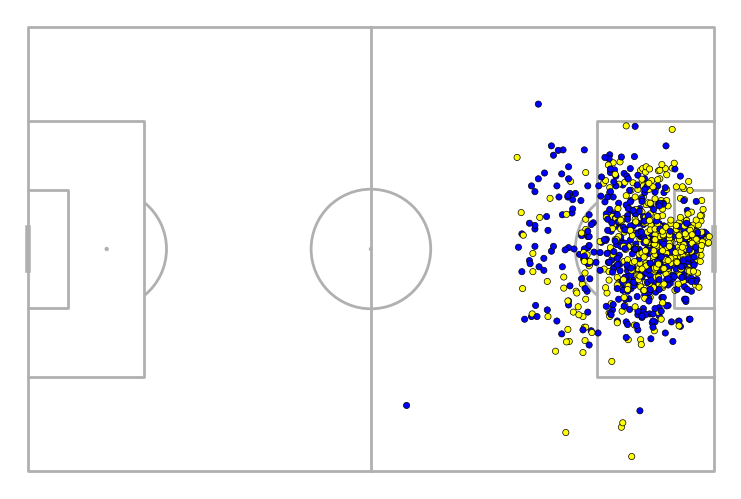

In [1651]:
colors = ['blue' if i else 'yellow' for i in goals.RightFoot]

fig, ax = pitch.draw(figsize=(10.5*0.75, 6.8*0.75))

sc = pitch.scatter(
    goals['x'], goals['y'],                     # Shot coordinates
    c=colors,                                   # Footedness for color
    edgecolors='black', linewidth=0.5, s=20,    # Point styling
    ax=ax
)


In [1652]:
table = pd.crosstab(data['RightFoot'], data['is_goal'], margins=True)

table.index = ['Left Foot', 'Right Foot', 'Total']
table.columns = ['No Goal', 'Goal', 'Total']

table

,No Goal,Goal,Total
Left Foot,3613,493,4106
Right Foot,3484,499,3983
Total,7097,992,8089


***The data shows a balanced distribution of shots between left- and right-footed attempts, with comparable goal totals. 
Conversion rates are also very similar (≈12.0% for left foot vs ≈12.6% for right foot), indicating no significant advantage for either foot in overall finishing efficiency.***

### ***Zonal Analysis***

In [1653]:
pitch_side_data = data[["x", "y", "is_goal"]]
pitch_side_data["pitch_side"] = [   "R" if i.y<=34 else
                                    "L" if i.y>=66
                                    else "C" 
                                for _, i in data.iterrows()]


pitch_side_goals = pitch_side_data[pitch_side_data.is_goal==True]

# pitch_side_data.head()
pitch_side_goals.head()

,x,y,is_goal,pitch_side
27,74.5,46.0,True,C
29,97.0,53.2,True,C
50,88.5,50.0,True,C
70,89.0,55.8,True,C
80,88.5,56.7,True,C


In [1654]:
pitch_side_data.pitch_side.value_counts()

pitch_side
C    6201
L     974
R     914
Name: count, dtype: int64

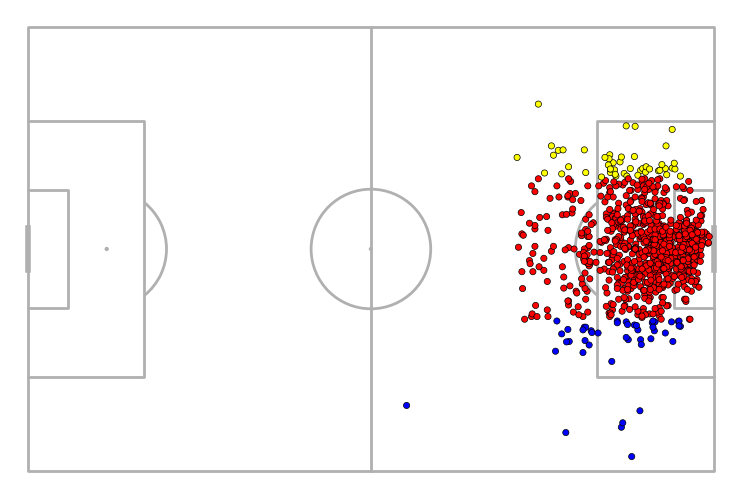

In [1655]:
colors = ['blue' if i=="R" else 
          'yellow' if i=="L" 
           else "red" for i in pitch_side_goals.pitch_side]

fig, ax = pitch.draw(figsize=(10.5*0.75, 6.8*0.75))

sc = pitch.scatter(
    pitch_side_goals['x'], pitch_side_goals['y'],                     # Shot coordinates
    c=colors,                                   # Footedness for color
    edgecolors='black', linewidth=0.5, s=20,    # Point styling
    ax=ax
)


In [1656]:
table = pd.crosstab(pitch_side_data['pitch_side'], pitch_side_data['is_goal'], margins=True)

table.index = ['Center', 'Left Side', 'Right Side', 'Total']
table.columns = ['No Goal', 'Goal', 'Total']

table

,No Goal,Goal,Total
Center,5303,898,6201
Left Side,926,48,974
Right Side,868,46,914
Total,7097,992,8089


In [1657]:
table = round(pd.crosstab(pitch_side_data['pitch_side'], pitch_side_data['is_goal'], normalize='index')*100, 2)

table.index = ['Center', 'Left Side', 'Right Side']
table.columns = ['No Goal', 'Goal']

table

,No Goal,Goal
Center,85.52,14.48
Left Side,95.07,4.93
Right Side,94.97,5.03


***Shots taken from central areas have a significantly higher conversion rate (~14.5%) compared to wide areas (~5%), representing nearly a threefold increase in efficiency.***

***This is primarily driven by more favorable shooting angles, as central positions provide a wider view of the goal, making it easier to find scoring opportunities. Additionally, central shots are often taken from closer distances and higher-quality situations, which further contributes to the increased conversion rate.***

***Central positions also allow for a greater variety of finishing options, potentially making it more difficult for goalkeepers to anticipate shot direction.***

### ***Footedness/Zonal Analysis***

In [1658]:
pitch_side_foot_data = pitch_side_data 
pitch_side_foot_data["foot"] = data.RightFoot.apply(lambda x: "R" if x==True else "L")

pitch_side_foot_data.head()

,x,y,is_goal,pitch_side,foot
0,80.8,51.6,False,C,L
1,79.3,24.2,False,R,R
2,80.0,59.5,False,C,R
3,89.8,55.6,False,C,L
4,84.9,56.2,False,C,L


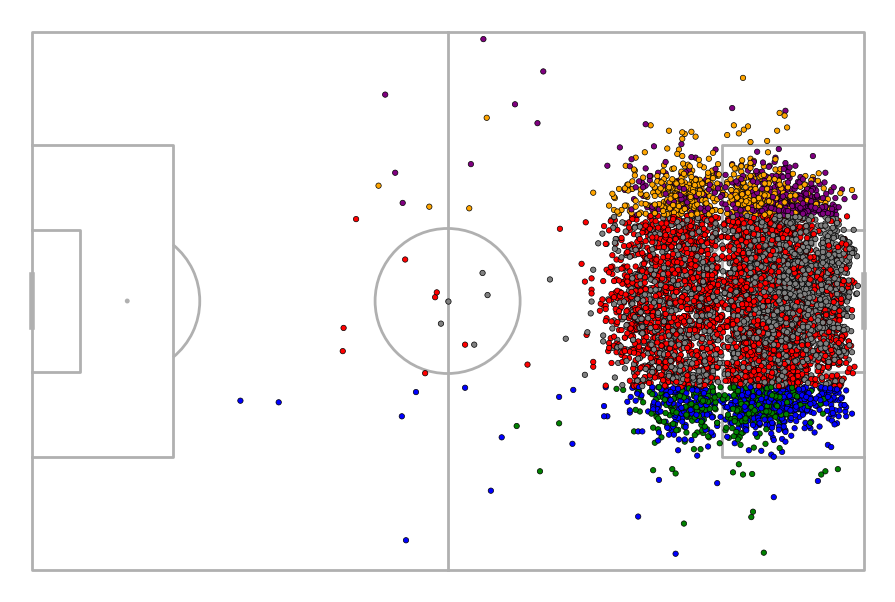

In [1659]:
colors = [
    'blue'   if (row['pitch_side'] == "R" and row['foot'] == "R") else
    'green'  if (row['pitch_side'] == "R" and row['foot'] == "L") else
    'orange' if (row['pitch_side'] == "L" and row['foot'] == "R") else
    'purple' if (row['pitch_side'] == "L" and row['foot'] == "L") else
    'red' if (row['pitch_side'] == "C" and row['foot'] == "R") else
    'grey'
    for _, row in pitch_side_foot_data.iterrows()
]

fig, ax = pitch.draw(figsize=(10.5*0.9, 6.8*0.9))

sc = pitch.scatter(
pitch_side_foot_data['x'], pitch_side_foot_data['y'],       # Shot coordinates
    c=colors,                                               # Footedness for Zone/color
    edgecolors='black', linewidth=0.5, s=15,                # Point styling
    ax=ax
)


In [1660]:
table = pd.crosstab(
    index=[
        pitch_side_foot_data['pitch_side'].map({'L': 'Left Side', 'R': 'Right Side', 'C': 'Center'}),
        pitch_side_foot_data['foot'].map({'L': 'Left Foot', 'R': 'Right Foot'})
    ],
    columns=pitch_side_foot_data['is_goal'],
    margins=True
)

table.columns = ['No Goal', 'Goal', 'Total']
table.index.names = ['Foot', 'Pitch Side']

table

No Goal  Goal  Total
Foot       Pitch Side                      
Center     Left Foot      2855   450   3305
           Right Foot     2448   448   2896
Left Side  Left Foot       414    21    435
           Right Foot      512    27    539
Right Side Left Foot       344    22    366
           Right Foot      524    24    548
All                       7097   992   8089

In [1661]:
table = round(pd.crosstab(
    index=[
        pitch_side_foot_data['pitch_side'].map({'L': 'Left Side', 'R': 'Right Side', 'C': 'Center'}),
        pitch_side_foot_data['foot'].map({'L': 'Left Foot', 'R': 'Right Foot'})
    ],
    columns=pitch_side_foot_data['is_goal'],
    normalize='index'
)*100, 2)

table.columns = ['No Goal', 'Goal']
table.index.names = ['Foot', 'Pitch Side']

table

No Goal   Goal
Foot       Pitch Side                
Center     Left Foot     86.38  13.62
           Right Foot    84.53  15.47
Left Side  Left Foot     95.17   4.83
           Right Foot    94.99   5.01
Right Side Left Foot     93.99   6.01
           Right Foot    95.62   4.38

***Within central areas, right-footed shots show a slightly higher conversion rate (~15.5%) compared to left-footed shots (~13.6%). However, this difference is relatively small and may be influenced by underlying factors such as sample imbalance, player distribution, and chance quality rather than a true finishing advantage.***
***In central positions, where shooting angles are already optimal, differences in body orientation are less impactful, suggesting that this variation is more likely driven by contextual factors than shooting mechanics.***

***In wide areas, shots taken with the opposite foot (open-body orientation) consistently show higher conversion rates compared to same-side footed shots. On the left side, right-footed shots outperform left-footed ones (5.36% vs 4.83%), while on the right side, left-footed shots are more effective (6.01% vs 4.38%).***
***This suggests that open-body shooting angles, which allow for curling finishes toward the far post, provide a measurable advantage over closed-body situations, where players are often limited to tighter angles and more predictable shot trajectories.***

# ***Shot Geometery Analysis***

***In this section, I analyze how "Shot Distance" and "Shooting Angle" influence goal conversion rates. These spatial factors are fundamental in determining shot quality, as they directly affect the player’s view of the goal and the likelihood of successfully beating the goalkeeper.***

### ***Data Preparation***

***The dataset includes (x, y) coordinates indicating the location of each shot. In this coordinate system, the center of the goal is defined as (100, 50) with length of 7.32m on official pitchs [105x68m]. Using these reference points, I will derive two fundamental spatial features:***

- ***1- Euclidean distance between the shot location and the center of the goal***
- ***2- The shooting angle formed between the shot location and the two goalposts, capturing the visible area of the goal (0 &rarr; 180)***

In [1663]:
geometery_data = data[['x', 'y']].copy()
geometery_data['E_dis'] = round(np.sqrt( (100-geometery_data['x'])**2 + (geometery_data['y']-50)**2 ), 2)

geometery_data.head()

,x,y,E_dis
0,80.8,51.6,19.27
1,79.3,24.2,33.08
2,80.0,59.5,22.14
3,89.8,55.6,11.64
4,84.9,56.2,16.32


In [1664]:
# Goal posts
pitch_normalization_factor = 68/100
goal_y_top = 50 + 3.66*pitch_normalization_factor
goal_y_bottom = 50 - 3.66*pitch_normalization_factor


# Distances to posts
a = np.sqrt((100 - geometery_data['x'])**2 + (goal_y_top - geometery_data['y'])**2)
b = np.sqrt((100 - geometery_data['x'])**2 + (goal_y_bottom - geometery_data['y'])**2)
c = 7.32  # goal width


# Cosine rule
cos_value = (a**2 + b**2 - c**2) / (2 * a * b)
cos_value = np.clip(cos_value, -1, 1)
geometery_data['Theta'] = np.arccos(cos_value)

geometery_data['Theta_deg'] = round(np.degrees(geometery_data['Theta']), 5)

geometery_data.drop(columns=['Theta'], inplace=True)
geometery_data['is_goal'] = data['is_goal']

geometery_data.head()

,x,y,E_dis,Theta_deg,is_goal
0,80.8,51.6,19.27,21.68692,False
1,79.3,24.2,33.08,10.77610,False
2,80.0,59.5,22.14,18.12964,False
3,89.8,55.6,11.64,34.21110,False
4,84.9,56.2,16.32,24.82854,False


### ***Shot Distance Analysis***

In [1665]:
geometery_data.E_dis.describe()

count    8089.000000
mean       18.487239
std         7.997360
min         1.580000
25%        12.060000
50%        18.380000
75%        24.190000
max        77.150000
Name: E_dis, dtype: float64

In [1666]:
geometery_data['E_dis_zone'] = geometery_data['E_dis'].apply(lambda x: '[50-120]' if 50 <= x < 120 else
                                                                        '[30-50]' if 30 <= x < 50 else
                                                                        '[20-30]' if 20 <= x < 30 else
                                                                        '[10-20]' if 10 <= x < 20 else
                                                                        '[5-10]' if 5 <= x < 10 else
                                                                        '[0-5]' if 0 <= x < 5 else
                                                                        'NaN'
    )

new_order = ['x', 'y', 'E_dis', 'E_dis_zone', 'Theta_deg', 'is_goal']
geometery_data = geometery_data[new_order]
geometery_data.head()

,x,y,E_dis,E_dis_zone,Theta_deg,is_goal
0,80.8,51.6,19.27,[10-20],21.68692,False
1,79.3,24.2,33.08,[30-50],10.77610,False
2,80.0,59.5,22.14,[20-30],18.12964,False
3,89.8,55.6,11.64,[10-20],34.21110,False
4,84.9,56.2,16.32,[10-20],24.82854,False


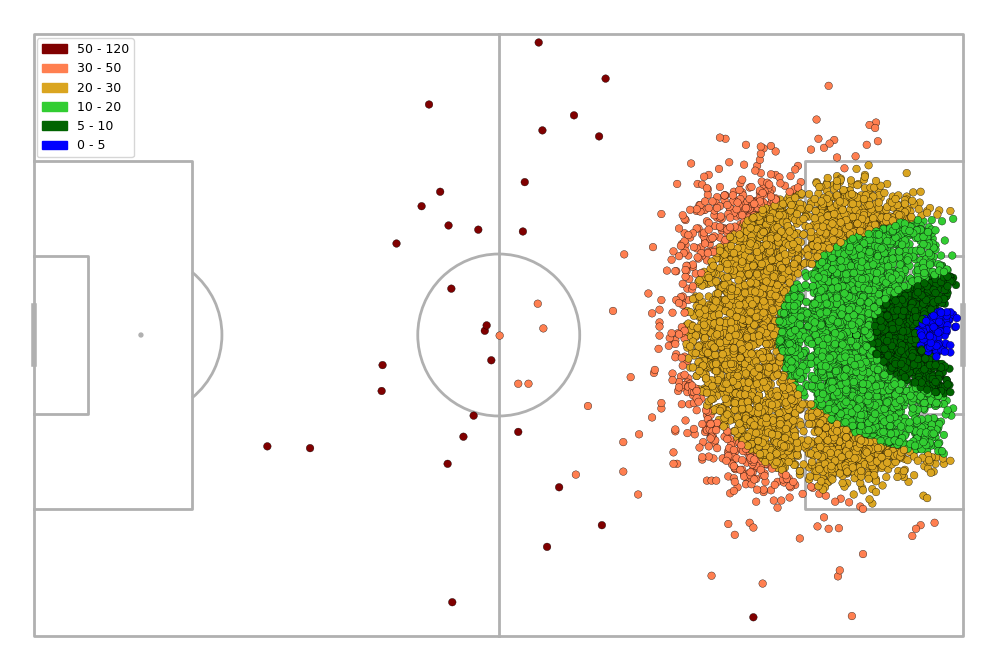

In [1667]:
colors = [
    'maroon'      if i == '[50-120]' else
    'coral'    if i == '[30-50]' else
    'goldenrod' if i == '[20-30]' else
    'limegreen' if i == '[10-20]' else
    'darkgreen' if i == '[5-10]' else
    'blue'     if i == '[0-5]' else
    'black' for i in geometery_data['E_dis_zone']
]

fig, ax = pitch.draw(figsize=(10.5*1, 6.8*1))

sc = pitch.scatter(
    geometery_data['x'], geometery_data['y'],            # Shot coordinates
    c=colors,                                            # Distance for color
    edgecolors='black', linewidth=0.25, s=30, alpha=1,      # Point styling
    ax=ax
)

legend_elements = [
    mpatches.Patch(color='maroon', label='50 - 120'),
    mpatches.Patch(color='coral', label='30 - 50'),
    mpatches.Patch(color='goldenrod', label='20 - 30'),
    mpatches.Patch(color='limegreen', label='10 - 20'),
    mpatches.Patch(color='darkgreen', label='5 - 10'),
    mpatches.Patch(color='blue', label='0 - 5')
]


ax.legend(
    handles=legend_elements,
    loc='center',
    bbox_to_anchor=(0.077, 0.865),
    fontsize=9,   
    title_fontsize=16   
)

In [1668]:
counts = pd.crosstab(
    geometery_data['E_dis_zone'],
    geometery_data['is_goal'],
    margins=True,
    margins_name='Total'
)

percentages = round(counts.div(counts['Total'], axis=0) * 100, 2)

result = pd.DataFrame({
    'Goal (%)': percentages[True],
    'No Goal (%)': percentages[False],
    'Total': counts['Total']
}).drop('Total').sort_values('Goal (%)', ascending=False)

result

,Goal (%),No Goal (%),Total
E_dis_zone,,,
[0-5],56.99,43.01,186
[5-10],22.00,78.00,1082
[10-20],13.95,86.05,3483
[20-30],5.03,94.97,2805
[30-50],3.98,96.02,503
[50-120],3.33,96.67,30


***The data shows a clear relationship between shot distance and scoring probability. Shots taken from very close range (~[0–12 m]) have the highest chance of resulting in a goal (≈25.5%), while shots from longer distances like (~[24.2–100 m]) are far less likely to score (≈4.5%). Intermediate distances show a gradual decline in conversion rate, highlighting how proximity to goal strongly influences scoring likelihood.***

***This is very intuitive, close-range shots give attackers more space, time, and flexibility in shot selection, while longer-range attempts demand greater precision and are more easily stopped by goalkeepers.***

### ***Goal Angle Analysis***

In [1669]:
geometery_data.Theta_deg.describe()

count    8089.000000
mean       26.928412
std        18.955807
min         5.362970
25%        15.595640
50%        20.781420
75%        31.974340
max       180.000000
Name: Theta_deg, dtype: float64

In [1670]:
geometery_data['Theta_zone'] = geometery_data['Theta_deg'].apply(lambda x: '[90-180]' if 90 <= x <= 180 else
                                                                            '[45-90]' if 45 <= x < 90 else
                                                                            '[30-45]' if 30 <= x < 45 else
                                                                            '[20-30]' if 20 <= x < 30 else
                                                                            '[15-20]' if 15 <= x < 20 else
                                                                            '[10-15]' if 10 <= x < 15 else
                                                                            '[0-10]' if 0 <= x < 10 else
                                                                            'NaN')

new_order = ['x', 'y', 'E_dis', 'E_dis_zone', 'Theta_deg', 'Theta_zone', 'is_goal']
geometery_data = geometery_data[new_order]
geometery_data.head()

,x,y,E_dis,E_dis_zone,Theta_deg,Theta_zone,is_goal
0,80.8,51.6,19.27,[10-20],21.68692,[20-30],False
1,79.3,24.2,33.08,[30-50],10.77610,[10-15],False
2,80.0,59.5,22.14,[20-30],18.12964,[15-20],False
3,89.8,55.6,11.64,[10-20],34.21110,[30-45],False
4,84.9,56.2,16.32,[10-20],24.82854,[20-30],False


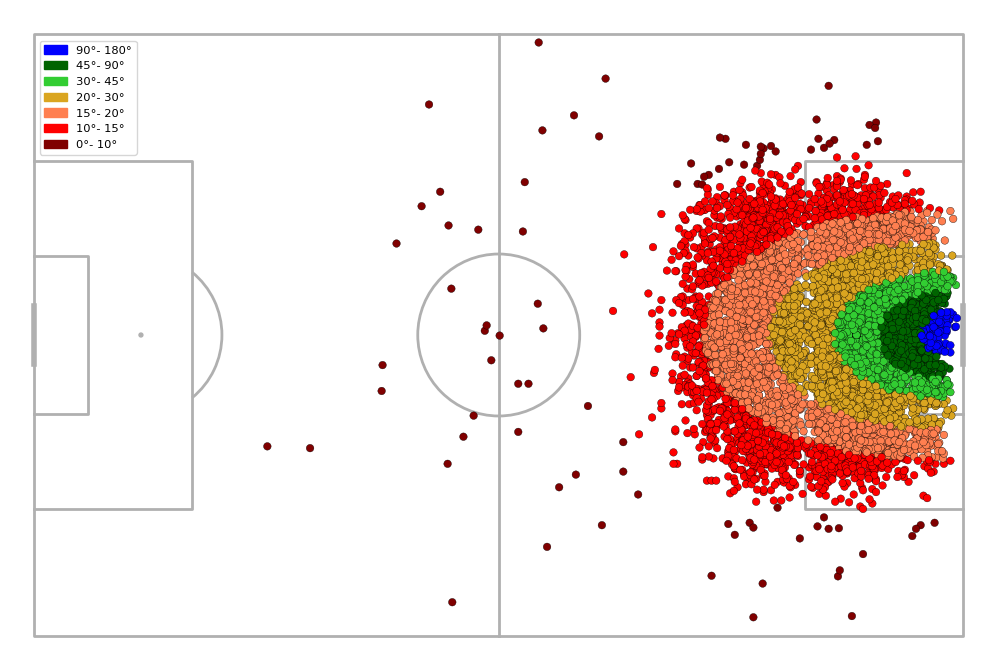

In [1671]:
colors = [
    'blue'      if i == '[90-180]' else
    'darkgreen' if i == '[45-90]' else
    'limegreen' if i == '[30-45]' else
    'goldenrod' if i == '[20-30]' else
    'coral'     if i == '[15-20]' else
    'red'       if i == '[10-15]' else
    'maroon'    if i == '[0-10]' else
    'black' for i in geometery_data['Theta_zone']
]

fig, ax = pitch.draw(figsize=(10.5*1, 6.8*1))

sc = pitch.scatter(
    geometery_data['x'], geometery_data['y'],               # Shot coordinates
    c=colors,                                               # Goal Angle for color
    edgecolors='black', linewidth=0.25, s=30, alpha=1,         # Point styling
    ax=ax
)

legend_elements = [
    mpatches.Patch(color='blue', label='90°- 180°'),
    mpatches.Patch(color='darkgreen', label='45°- 90°'),
    mpatches.Patch(color='limegreen', label='30°- 45°'),
    mpatches.Patch(color='goldenrod', label='20°- 30°'),
    mpatches.Patch(color='coral', label='15°- 20°'),
    mpatches.Patch(color='red', label='10°- 15°'),
    mpatches.Patch(color='maroon', label='0°- 10°')
]

ax.legend(
    handles=legend_elements,
    loc='center',
    bbox_to_anchor=(0.08, 0.865),
    fontsize=8.25,   
    title_fontsize=10   
)

In [1672]:
counts = pd.crosstab(
    geometery_data['Theta_zone'],
    geometery_data['is_goal'],
    margins=True,
    margins_name='Total'
)

percentages = round(counts.div(counts['Total'], axis=0) * 100, 2)

result = pd.DataFrame({
    'Goal (%)': percentages[True],
    'No Goal (%)': percentages[False],
    'Total': counts['Total']
}).drop('Total').sort_values('Goal (%)', ascending=False)

result

,Goal (%),No Goal (%),Total
Theta_zone,,,
[90-180],61.90,38.10,147
[45-90],26.96,73.04,738
[30-45],19.46,80.54,1403
[20-30],11.48,88.52,1942
[0-10],7.69,92.31,91
[15-20],6.22,93.78,2186
[10-15],3.98,96.02,1582



***REDO AFTER CHANGE***

***The data clearly shows that shot angle has a big impact on scoring chances. Shots from very wide angles ([31.9–180]°) are the most likely to result in a goal, with around a 25.6% success rate, while shots from tight angles ([0–15.5]°) barely find the net, converting only about 4% of the time. In between, there’s a steady drop in scoring as the angle narrows, which makes sense—goalkeepers struggle more with shots coming from wider positions because the shooter has more options and a bigger slice of the goal to aim at.***

***From a tactical perspective, this aligns with what footballers often know intuitively: being slightly off-center with a wider approach to goal gives you more room to play with, whereas shooting from a very tight angle demands extreme precision.***

# ***Impact of Match Period on Scoring Efficiency***

***In this section, I examine the impact of match period on shot conversion.***

- ***Does physical fatigue lead to a decline in attacking efficiency as the game progresses?***
- ***Alternatively, does mental fatigue reduce defensive organization, resulting in increased scoring opportunities?***

In [1673]:
data.head()

,x,y,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,BigChance,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OtherBodyPart,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,is_goal
0,80.8,51.6,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
1,79.3,24.2,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
2,80.0,59.5,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
3,89.8,55.6,True,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
4,84.9,56.2,True,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False


In [1674]:
period_data = data[['x', 'y', 'period_FirstHalf', 'period_SecondHalf', 'is_goal']].copy()
period_data.head()

,x,y,period_FirstHalf,period_SecondHalf,is_goal
0,80.8,51.6,False,True,False
1,79.3,24.2,False,True,False
2,80.0,59.5,False,True,False
3,89.8,55.6,False,True,False
4,84.9,56.2,False,True,False


In [1675]:
period_data['Period'] = period_data['period_FirstHalf'].apply(lambda x: 1 if x else 2)

new_order = ['x', 'y', 'Period', 'is_goal']
period_data = period_data[new_order]
period_data.head()

,x,y,Period,is_goal
0,80.8,51.6,2,False
1,79.3,24.2,2,False
2,80.0,59.5,2,False
3,89.8,55.6,2,False
4,84.9,56.2,2,False


In [1676]:
counts = pd.crosstab(
    period_data['Period'],
    period_data['is_goal'],
    margins=True,
    margins_name='Total'
)

percentages = round(counts.div(counts['Total'], axis=0) * 100, 2)

result = pd.DataFrame({
    'Goal (%)': percentages[True],
    'No Goal (%)': percentages[False],
    'Total': counts['Total']
}).drop('Total').sort_values('Goal (%)', ascending=False)

result

,Goal (%),No Goal (%),Total
Period,,,
2,12.63,87.37,4332
1,11.84,88.16,3757


***The data shows a very slight increase in conversion rate during the second half (≈12.7%) compared to the first half (≈11.9%), although the difference is minimal. This suggests that while there may be a small tendency for more goals later in the game—potentially due to fatigue, tactical changes, or more open play—the overall impact of match period on shot conversion appears relatively weak, almost negligible.***

# ***Final Modifications***

## ***Add/Normalize Engineered Features***

In [1677]:
data['Norm_E_dis'] = (geometery_data['E_dis'] / geometery_data['E_dis'].max()).clip(0, 1)
data['Norm_Theta'] = geometery_data['Theta_deg']/180

data.head()

,x,y,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,BigChance,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OtherBodyPart,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,is_goal,Norm_E_dis,Norm_Theta
0,80.8,51.6,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.249773,0.120483
1,79.3,24.2,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.428775,0.059867
2,80.0,59.5,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.286973,0.100720
3,89.8,55.6,True,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.150875,0.190062
4,84.9,56.2,True,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.211536,0.137936


In [1678]:
data.Norm_E_dis.describe()

count    8089.000000
mean        0.239627
std         0.103660
min         0.020480
25%         0.156319
50%         0.238237
75%         0.313545
max         1.000000
Name: Norm_E_dis, dtype: float64

In [1679]:
data.Norm_Theta.describe()

count    8089.000000
mean        0.149602
std         0.105310
min         0.029794
25%         0.086642
50%         0.115452
75%         0.177635
max         1.000000
Name: Norm_Theta, dtype: float64

## ***Back From The Future...*** 

### 🔍 Feature Leakage & Proxy Variable: *BigChance*

While analyzing the Random Forest model, I observed that the **`BigChance`** feature was overwhelmingly dominating the model’s decision-making process.

Upon further reflection, I realized that *BigChance* is not a raw, objective feature. Instead, it is a **subjective label**, typically assigned by human analysts to describe situations where a player is expected to score.

This introduces two key issues:

* **Feature Leakage (or near-leakage):**
  The feature partially encodes the target variable (*goal probability*), meaning the model is indirectly accessing information it is supposed to learn on its own.

* **Proxy Variable Problem:**
  *BigChance* effectively acts as a proxy for expected goals (xG), functioning like a simplified version of another model’s judgment rather than an independent input feature.

As a result, the model risks **learning to replicate subjective human assessments** instead of discovering underlying patterns from objective data such as shot distance, angle, and context.

---

### ✅ Decision

To improve model integrity, interpretability, and generalization, I decided to:

* **Remove the `BigChance` feature**
* Replace it with a **data-driven alternative** constructed from objective variables

---

### ⚙️ Replacing Subjective Labels with Objective Features

Instead of relying on a human-defined label, I engineered a new feature to capture “chance quality” using underlying data such as:

* Shot distance (`E_dis`)
* Shot angle (`Theta_deg`)
* Situational context (e.g., `OneOnOne`)

This allows the model to approximate the concept of a “big chance” while remaining:

* **Objective**
* **Transparent**
* **Fully derived from the data**

---

### 🎯 Goal Moving Forward

Build an xG model that:

* Relies on **objective features**
* Learns **scoring probability from first principles**
* Avoids subjective bias and hidden leakage
* Produces **interpretable and generalizable predictions**


In [1680]:
data.drop(columns=['BigChance'], inplace=True)

data['ChanceQuality'] = ( 0.3*(1 - data['Norm_E_dis']) + 0.5*data['Norm_Theta'] + 0.2*(1 + data['OneOnOne']) )

In [1681]:
data.ChanceQuality.describe()

count    8089.000000
mean        0.507883
std         0.085685
min         0.214897
25%         0.449289
50%         0.486822
75%         0.547864
max         0.993856
Name: ChanceQuality, dtype: float64

In [1682]:
data.head()

,x,y,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OtherBodyPart,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,is_goal,Norm_E_dis,Norm_Theta,ChanceQuality
0,80.8,51.6,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.249773,0.120483,0.485309
1,79.3,24.2,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.428775,0.059867,0.401301
2,80.0,59.5,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.286973,0.100720,0.464268
3,89.8,55.6,True,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.150875,0.190062,0.549768
4,84.9,56.2,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.211536,0.137936,0.505507


In [1683]:
is_goal = data['is_goal']
data.drop(columns='is_goal', inplace=True)
data['is_goal'] = is_goal

In [1684]:
data.sort_values('ChanceQuality', ascending=False).head(10)

,x,y,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OtherBodyPart,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,Norm_E_dis,Norm_Theta,ChanceQuality,is_goal
5986,99.1,51.3,True,False,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,0.020480,1.0,0.993856,True
6775,99.2,51.4,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,0.020868,1.0,0.993739,True
4797,98.2,50.5,True,False,True,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,0.024238,1.0,0.992728,False
6531,98.2,50.8,True,False,True,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,0.025535,1.0,0.992340,True
6483,98.0,49.9,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,0.025924,1.0,0.992223,True
6508,98.6,48.3,True,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,0.028516,1.0,0.991445,False
6161,98.3,51.6,True,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,0.030201,1.0,0.990940,True
6151,98.1,48.6,True,False,True,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,0.030590,1.0,0.990823,True
391,97.8,51.2,True,False,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,0.032534,1.0,0.990240,True
7506,97.5,50.6,True,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,0.033312,1.0,0.990006,False


In [1685]:
data.sort_values('ChanceQuality', ascending=True).head(10)

,x,y,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OtherBodyPart,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,Norm_E_dis,Norm_Theta,ChanceQuality,is_goal
3037,25.1,31.5,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,1.000000,0.029794,0.214897,False
3737,29.7,31.2,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,0.943227,0.031518,0.232791,False
942,45.0,5.6,False,True,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.916137,0.029815,0.240066,False
3002,42.5,88.3,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,0.895528,0.031245,0.246964,False
5851,54.3,98.6,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,0.864679,0.030356,0.255774,False
1962,37.4,40.7,False,True,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,0.820350,0.036626,0.272208,False
1443,39.0,65.2,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,0.814906,0.036555,0.273806,False
1368,37.5,45.0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,False,False,0.812703,0.037099,0.274739,False
5932,41.7,71.4,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,0.804925,0.036473,0.276759,False
114,43.7,73.8,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,False,False,0.792223,0.036760,0.280713,False


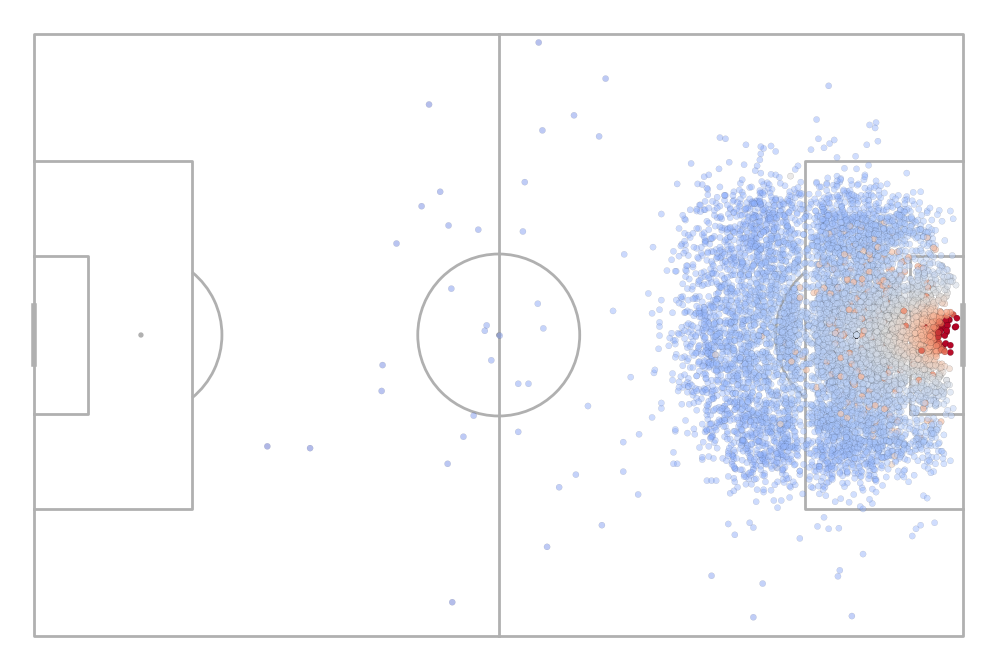

In [1686]:
fig, ax = pitch.draw(figsize=(10.5*1, 6.8*1))

sc = pitch.scatter(
    data['x'], data['y'],                                                                   # Shot coordinates
    c=data['ChanceQuality'],                                                                # Chance Quality for color
    cmap='coolwarm',                                                                
    edgecolors='black', linewidth=0.1, s=20, alpha=data['ChanceQuality'].clip(0.4, 1),      # Point styling
    ax=ax
    )

# ***Save Data***

In [1687]:
data.to_excel("data/clean_EDA_data.xlsx", index=False)